# 5.0 — Discount: Real Effect, Statistical Mirage, or Untestable?

`0.2_sales_corr.ipynb` and `0.3_prod_category_analyzis.ipynb` both found discount looking like noise at the category-average level (`TO_INVESTIGATE.TXT` §0.2/§0.3/KEY TAKEAWAYS: *"discount idk what is happening wtf"*, *"discounts seem useless in this dataset"*). A category average can hide a threshold effect — discount might only move behavior above/below some rate, or only for certain segments — so before signing off on "useless" this notebook re-cuts discount vs. order size at finer grain (bins, segments, per-order), and if the data genuinely can't settle the question, proposes a controlled experiment instead of another observational cut.

**Analysis window**: Jan 2015 – Sep 2017, same reason as `0.1`/`0.7`/`0.8` — the Nov 2017+ artifact collapses every order to 1 line item, which would fake the exact "does discount relate to basket size" signal this notebook is testing for.

## 1. Load & prep

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def dollars(v, _):
    return f'${v:,.0f}'

DATA_DIR = '.'
BINS = [-0.01, 0, 0.05, 0.10, 0.15, 0.20, 0.26]
BIN_LABELS = ['0%', '1-5%', '6-10%', '11-15%', '16-20%', '21-25%']

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
clean = df[df['order date (DateOrders)'] < '2017-10-01'].copy()
clean['disc_bin'] = pd.cut(clean['Order Item Discount Rate'], bins=BINS, labels=BIN_LABELS)

print(f"{clean.shape[0]:,} order lines, {clean['Order Id'].nunique():,} orders")
clean['Order Item Discount Rate'].describe()

171,962 order lines, 57,349 orders


count    171962.000000
mean          0.101676
std           0.070413
min           0.000000
25%           0.040000
50%           0.100000
75%           0.160000
max           0.250000
Name: Order Item Discount Rate, dtype: float64

Discount rate is a per-line-item field ranging 0%–25% in fixed 1-point-ish steps (mean 10.2%, std 7.0pp) — every line item in every order carries its own independently-set rate; there's no order-level or customer-level discount policy visible in the schema.

## 2. Is discount assigned independently of everything, even before binning?

In [3]:
checks = pd.DataFrame({
    'mean_discount': [
        clean['Order Item Discount Rate'].mean(),
        clean.groupby('Category Name')['Order Item Discount Rate'].mean().std(),
        clean.groupby('Customer Segment')['Order Item Discount Rate'].mean().std(),
        clean.groupby('Market')['Order Item Discount Rate'].mean().std(),
    ],
}, index=['overall mean', 'std of category means (32 cats)', 'std of segment means (3 segs)', 'std of market means (5 markets)'])
checks.round(4)

,mean_discount
overall mean,0.1017
std of category means (32 cats),0.0030
std of segment means (3 segs),0.0002
std of market means (5 markets),0.0001


In [4]:
corr_table = pd.Series({
    'vs. product price': clean['Order Item Discount Rate'].corr(clean['Order Item Product Price']),
    'vs. quantity': clean['Order Item Discount Rate'].corr(clean['Order Item Quantity']),
    'vs. profit ratio': clean['Order Item Discount Rate'].corr(clean['Order Item Profit Ratio']),
}, name='correlation with discount rate')
corr_table.round(4)

vs. product price    0.0008
vs. quantity         0.0001
vs. profit ratio    -0.0020
Name: correlation with discount rate, dtype: float64

Category, segment and market means all sit within a few tenths of a percentage point of the 10.2% overall mean — the kind of spread you'd get from averaging independent random draws, not a merchandising policy. Correlations with price, quantity and profit ratio round to zero (all |r| < 0.002). Nothing at the raw-field level distinguishes discount from noise. That's the premise `0.2`/`0.3` worked from — now the finer-grained checks.

## 3. Finer grain, take 1: binned discount vs. quantity, line-item level

In [5]:
g = clean.groupby('disc_bin', observed=True).agg(
    n=('Order Item Id', 'size'),
    mean_qty=('Order Item Quantity', 'mean'),
    se_qty=('Order Item Quantity', lambda s: s.std() / np.sqrt(len(s))),
    mean_profit_ratio=('Order Item Profit Ratio', 'mean'),
)
g

,n,mean_qty,se_qty,mean_profit_ratio
disc_bin,,,,
0%,9550,2.185654,0.015006,0.125587
1-5%,38210,2.181811,0.007501,0.118970
6-10%,38206,2.181699,0.007503,0.125028
11-15%,28664,2.183261,0.008664,0.119156
16-20%,38225,2.181269,0.007498,0.118408
21-25%,19107,2.184173,0.010615,0.119409


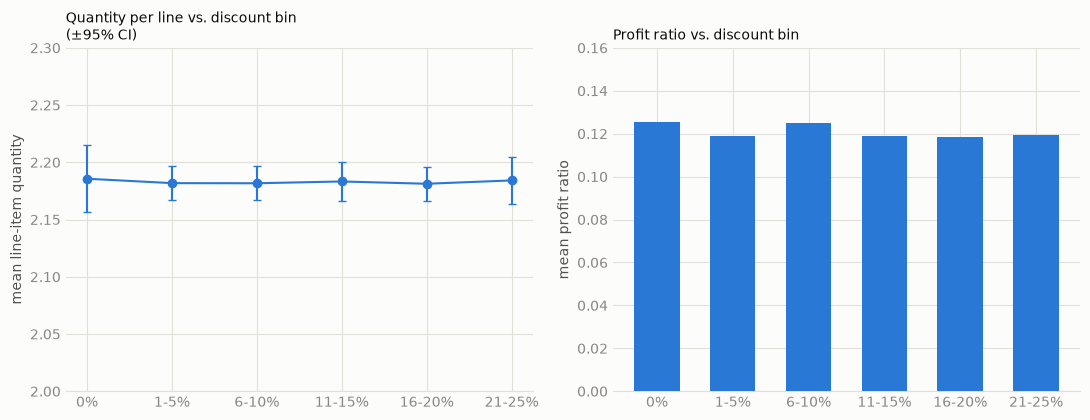

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
ax.errorbar(g.index, g['mean_qty'], yerr=g['se_qty'] * 1.96, fmt='o-', color=BLUE, capsize=3, zorder=3)
ax.set_ylim(2.0, 2.3)
ax.set_ylabel('mean line-item quantity')
ax.set_title('Quantity per line vs. discount bin\n(±95% CI)', loc='left', color=INK, fontsize=10)
style_axis(ax)

ax = axes[1]
ax.bar(g.index, g['mean_profit_ratio'], color=BLUE, width=0.6, zorder=3)
ax.set_ylim(0, 0.16)
ax.set_ylabel('mean profit ratio')
ax.set_title('Profit ratio vs. discount bin', loc='left', color=INK, fontsize=10)
style_axis(ax)

plt.tight_layout()
plt.show()

Flat within noise across all six bins, 0% through 21-25% — no kink, no threshold, no minimum discount that "switches on" bigger quantities. `Order Item Profit Ratio` is essentially a constant ~0.12-0.126 regardless of discount depth too (it's computed net of the discount already, so this mainly confirms margin-per-unit isn't quietly cratering at high discount either).

## 4. Finer grain, take 2: does it differ by segment?

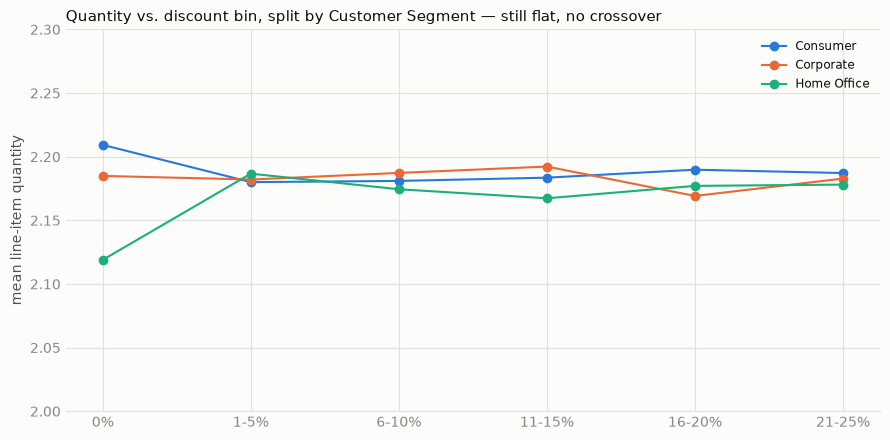

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for seg, color in zip(['Consumer', 'Corporate', 'Home Office'], [BLUE, ORANGE, CATEGORICAL[2]]):
    sub = clean[clean['Customer Segment'] == seg]
    seg_g = sub.groupby('disc_bin', observed=True)['Order Item Quantity'].mean()
    ax.plot(seg_g.index, seg_g.values, marker='o', color=color, label=seg, zorder=3)
ax.set_ylim(2.0, 2.3)
ax.set_ylabel('mean line-item quantity')
ax.set_title('Quantity vs. discount bin, split by Customer Segment — still flat, no crossover', loc='left', color=INK, fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5)
style_axis(ax)
plt.tight_layout()
plt.show()

No segment breaks from the pack and none shows its own threshold — the three lines sit on top of each other within noise. Whatever discount is doing in this dataset, it isn't doing it selectively by segment.

## 5. The pattern that *does* show up — and why it isn't real

In [8]:
order_agg = clean.groupby('Order Id').agg(
    n_lines=('Order Item Id', 'size'),
    total_qty=('Order Item Quantity', 'sum'),
    total_rev=('Order Item Total', 'sum'),
    mean_disc=('Order Item Discount Rate', 'mean'),
)
order_agg['disc_bin'] = pd.cut(order_agg['mean_disc'], bins=BINS, labels=BIN_LABELS)
order_view = order_agg.groupby('disc_bin', observed=True)[['n_lines', 'total_qty', 'total_rev']].mean()
order_view

,n_lines,total_qty,total_rev
disc_bin,,,
0%,1.050919,2.285714,205.154586
1-5%,2.367919,5.088322,462.652059
6-10%,3.286942,7.195369,602.605581
11-15%,3.376724,7.417229,590.835522
16-20%,2.473296,5.315997,408.641722
21-25%,1.492188,3.190104,233.511886


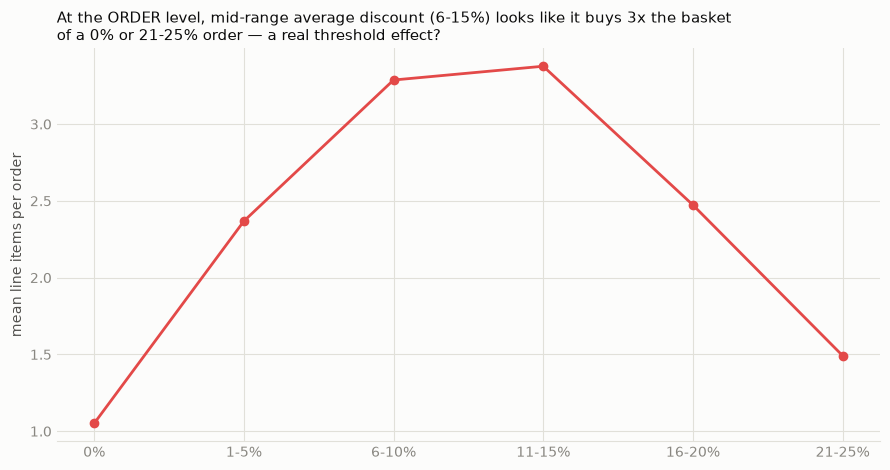

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(order_view.index, order_view['n_lines'], marker='o', color=NEG, linewidth=2, zorder=3)
ax.set_ylabel('mean line items per order')
ax.set_title("At the ORDER level, mid-range average discount (6-15%) looks like it buys 3x the basket\nof a 0% or 21-25% order — a real threshold effect?", loc='left', color=INK, fontsize=10.5)
style_axis(ax)
plt.tight_layout()
plt.show()

This looks exactly like the threshold effect worth finding: orders averaging 6-15% discount have ~3.3-3.4 line items, vs. ~1.0-1.5 for orders averaging 0% or 21-25%. Before writing that up, check whether it survives a null test — **randomly reshuffle every line's discount rate across the whole dataset**, keeping order structure (how many lines each order has) fixed, and rerun the exact same aggregation. If the shape disappears, it was real. If it doesn't, the order-level "pattern" isn't coming from discount behavior at all.

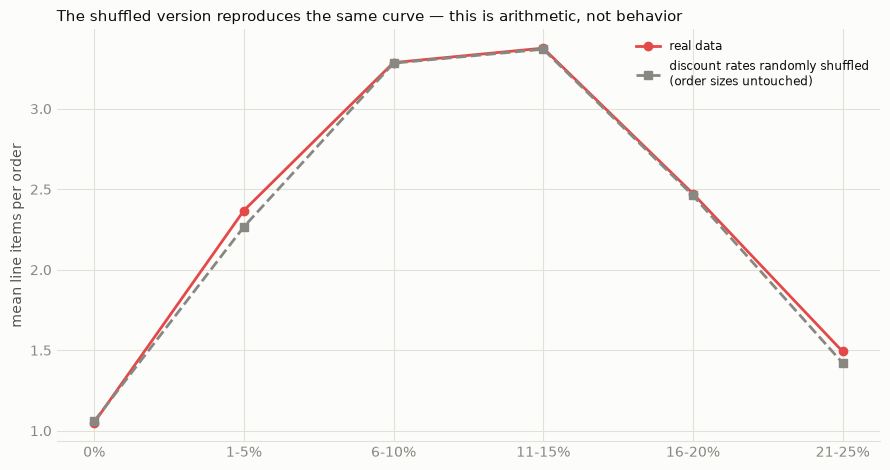

{'0%': 1.05, '1-5%': 2.37, '6-10%': 3.29, '11-15%': 3.38, '16-20%': 2.47, '21-25%': 1.49}
{'0%': 1.06, '1-5%': 2.27, '6-10%': 3.28, '11-15%': 3.37, '16-20%': 2.46, '21-25%': 1.42}


In [10]:
rng = np.random.default_rng(0)
shuffled = clean.copy()
shuffled['Order Item Discount Rate'] = rng.permutation(shuffled['Order Item Discount Rate'].values)

shuf_agg = shuffled.groupby('Order Id').agg(
    n_lines=('Order Item Id', 'size'),
    mean_disc=('Order Item Discount Rate', 'mean'),
)
shuf_agg['disc_bin'] = pd.cut(shuf_agg['mean_disc'], bins=BINS, labels=BIN_LABELS)
shuf_view = shuf_agg.groupby('disc_bin', observed=True)['n_lines'].mean()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(order_view.index, order_view['n_lines'], marker='o', color=NEG, linewidth=2, zorder=3, label='real data')
ax.plot(shuf_view.index, shuf_view.values, marker='s', color=INK_MUTED, linewidth=2, linestyle='--', zorder=3, label='discount rates randomly shuffled\n(order sizes untouched)')
ax.set_ylabel('mean line items per order')
ax.set_title('The shuffled version reproduces the same curve — this is arithmetic, not behavior', loc='left', color=INK, fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5)
style_axis(ax)
plt.tight_layout()
plt.show()

print(order_view['n_lines'].round(2).to_dict())
print(shuf_view.round(2).to_dict())

Identical curve, and the discount rates going into it were randomly reassigned. **This is regression to the mean, not a threshold effect.** A 1-line order's "average discount" is a single random draw, so it can land anywhere from 0% to 25% with equal probability — that's why the 0% and 21-25% bins are dominated by tiny orders. A 5-line order's "average discount" is the mean of five independent random draws, which by the central limit theorem clusters near the population mean (~10%) almost regardless of what those five discounts actually were — that's why the 6-15% bins are dominated by big orders. **Order size determines how extreme the average discount can look, not the other way around.** This is the same genre of artifact as the other three found in this archive (Nov 2017+ order-composition break, region rotation, fake customer IDs from `0.8`) — a mechanical property of how the data was generated, easy to mistake for a business finding if you stop at the order-level aggregate.

## 6. Verdict: this dataset can't settle the question

Every cut — category, segment, market, price, quantity, profit ratio, and the one order-level pattern that looked promising — comes back either flat-within-noise or explained away by an aggregation artifact. That's consistent with `Order Item Discount Rate` being assigned independently of customer behavior in how this dataset was generated, which means **no amount of re-cutting the existing data will find a real elasticity, because there isn't one encoded in it to find.**

Even setting the synthetic-data issue aside, this data is observational: discount and outcome are recorded together after the fact, so even a real correlation couldn't separate "the discount caused the bigger order" from "an already-bigger order attracted a bigger discount." Settling the actual business question — does discount move order size or conversion, and is there a threshold — needs a randomized experiment, not another cut of this file.

## 7. Proposed experiment design

In [11]:
order_rev = clean.groupby('Order Id')['Order Item Total'].sum()
rev_mean, rev_sd = order_rev.mean(), order_rev.std()
orders_per_month = clean.groupby(clean['order date (DateOrders)'].dt.to_period('M'))['Order Id'].nunique().mean()

alpha, power = 0.05, 0.80
z_alpha, z_beta = stats.norm.ppf(1 - alpha / 2), stats.norm.ppf(power)

print(f"baseline order value: mean ${rev_mean:,.0f}, sd ${rev_sd:,.0f}")
print(f"average orders/month in this business: {orders_per_month:,.0f}\n")

for rel_lift in [0.03, 0.05, 0.10]:
    delta = rev_mean * rel_lift
    n_per_arm = 2 * (z_alpha + z_beta) ** 2 * rev_sd ** 2 / delta ** 2
    print(f"detect a {rel_lift*100:.0f}% lift in AOV (${delta:,.0f}): {n_per_arm:,.0f} orders/arm needed")

baseline order value: mean $537, sd $309
average orders/month in this business: 1,738

detect a 3% lift in AOV ($16): 5,771 orders/arm needed
detect a 5% lift in AOV ($27): 2,078 orders/arm needed
detect a 10% lift in AOV ($54): 519 orders/arm needed


**Objective**: does discount rate cause a change in order value and/or purchase likelihood, and is the relationship linear or threshold-shaped? Test both magnitude (does *any* discount help) and shape (does a 20% discount outperform two separate 10% discounts) in one design.

**Unit of randomization**: customer, not order line. Randomizing within a customer's own repeat orders would contaminate the comparison (a customer who got a good deal once may behave differently next visit regardless of this order's discount) and this dataset already shows (`0.8`) that most customers are repeat buyers over a period of months — so assign each customer to one arm for the full experiment duration.

**Arms** — anchored to the range already in use operationally, plus one step beyond it to check for a threshold outside the observed 0-25% window:
- Control: 0% (no discount)
- Low: 10%
- High: 20%
- Beyond-range: 35% (tests whether the current 0-25% ceiling is already past the point of diminishing or negative returns on margin)

**Primary metric**: order conversion rate (did the customer purchase at all in the exposure window) — this is the metric the current dataset structurally *cannot* measure, since it only contains completed orders with no "saw an offer, didn't buy" denominator. **Secondary metric**: average order value among converters (directly comparable to §3-5 above). **Guardrail**: gross margin per customer over the window — a discount that lifts conversion but destroys margin is not a win.

**Stratify randomization by** `Customer Segment` and top-level product category at assignment time, sized to detect the heterogeneity this notebook's §4 didn't find in the observational data — segment-level and category-level treatment effects should be estimated as pre-specified secondary analyses, not just the pooled effect.

**Sample size**: using this dataset's own order-value variance (sd ≈ $309 per order) as the planning input, detecting a 5% relative lift in AOV needs roughly 2,100 orders per arm at 80% power / 5% significance. With ~1738 orders/month currently and 4 arms, that's about 0.3 months to power the AOV comparison alone — the conversion-rate comparison would need its own calc once a real baseline conversion rate exists (see the gap below), and will likely need a longer run since conversion deltas from discounting are typically single-digit percentage points on top of a baseline that itself isn't in this dataset.

**Analysis plan**: pre-registered regression of order value / conversion on arm assignment, with segment and category as covariates (not just the raw arm-vs-control diff-in-means used loosely above); Bonferroni or similar correction across the 3 treatment-vs-control comparisons and the segment/category interaction tests.

**The data-collection gap this experiment would need to close**: this file has no record of who was *offered* a discount and didn't buy — every row is a completed order. `tokenized_access_logs.csv` is the closest existing analog (browsing events) but only overlaps Sep 2017 - Jan 2018, isn't randomized, and can't be joined to a specific discount offer. Any real test needs the discount-assignment event logged at offer time, independent of whether a purchase followed.

## Takeaways

- **Discount rate is uncorrelated with price, quantity, and profit ratio (all |r| < 0.002), and its mean is nearly identical across every category, segment, and market checked** — consistent with it being assigned independently of customer behavior in this dataset, not a live merchandising lever.
- **No threshold effect at any grain checked**: binning discount into 6 bands and re-cutting by segment, the quantity and profit-ratio curves are flat within noise everywhere. `0.2`/`0.3`'s "useless" read holds up under finer-grained scrutiny.
- **One order-level pattern did look like a real threshold — a 6-15%-average-discount order has ~3x the line items of a 0% or 21-25% order — and it's a statistical mirage.** Reshuffling discount rates at random and rerunning the same aggregation reproduces the identical curve: it's regression-to-the-mean on an average of independent random draws, not a behavioral response. A 5th data-generation artifact for this archive, same family as the other four ([[dataco-supply-chain-archive]]).
- **This dataset cannot settle whether discount really drives behavior**, both because the discount field looks synthetic/random and because even a real correlation here would be observational, not causal. §7 above specs a randomized, customer-level, segment/category-stratified experiment (0% / 10% / 20% / 35% arms) with conversion rate as the primary metric and margin as a guardrail — and flags that the biggest blocker isn't sample size, it's that this data has no "offered, didn't buy" denominator to measure conversion against at all.